# Five-Bar Parallel Robot — Live Notebook

Drives the Arduino over USB serial and shows the linkage live with `ipympl`. Flash the firmware in `firmware/five_bar_ik/` and power the robot before running the cells. Run top to bottom on a fresh kernel.

In [1]:
%matplotlib widget

import sys
import time
import math
from pathlib import Path

import matplotlib.pyplot as plt
import serial

sys.path.insert(0, str(Path.cwd().parent / "host"))
import five_bar_client as fbc

In [ ]:
# Re-running this cell pulses DTR and resets the Arduino.
ser = serial.Serial("/dev/ttyUSB1", 115200, timeout=1.0)
time.sleep(2.0)
fbc.wait_for_ready(ser)

SerialException: [Errno 2] could not open port /dev/ttyUSB0: [Errno 2] No such file or directory: '/dev/ttyUSB0'

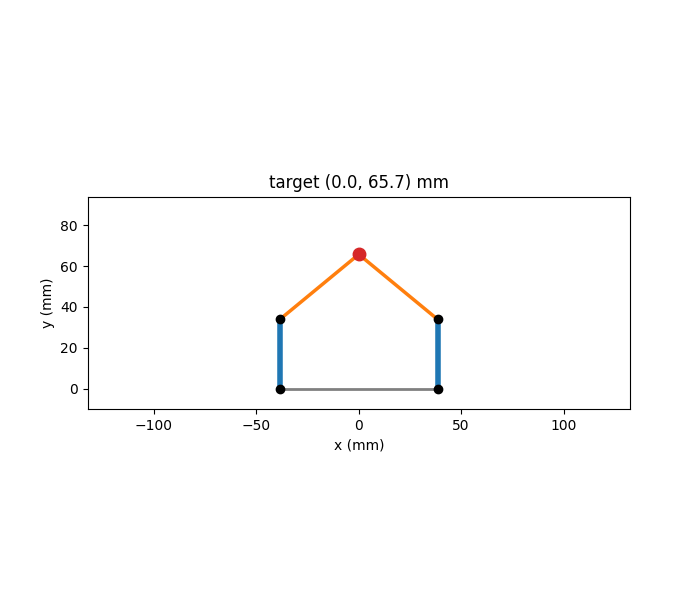

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
span_x = fbc.BASE_D / 2.0 + fbc.L1 + fbc.L2 + 10
ax.set_xlim(-span_x, +span_x)
ax.set_ylim(-10, fbc.L1 + fbc.L2 + 10)
ax.set_aspect("equal")
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")

base_line, = ax.plot([], [], color="gray", linewidth=2)
prox_left, = ax.plot([], [], color="tab:blue", linewidth=4)
prox_right, = ax.plot([], [], color="tab:blue", linewidth=4)
dist_left, = ax.plot([], [], color="tab:orange", linewidth=2.5)
dist_right, = ax.plot([], [], color="tab:orange", linewidth=2.5)
joints, = ax.plot([], [], "o", color="black", markersize=6)
ee_dot, = ax.plot([], [], "o", color="tab:red", markersize=9)

current = (math.pi / 2.0, math.pi / 2.0)

def redraw(th1, th2, title_xy=None):
    mL, eL, ee, eR, mR = fbc.forward_kinematics(th1, th2)
    base_line.set_data([mL[0], mR[0]], [mL[1], mR[1]])
    prox_left.set_data([mL[0], eL[0]], [mL[1], eL[1]])
    prox_right.set_data([mR[0], eR[0]], [mR[1], eR[1]])
    if ee is not None:
        dist_left.set_data([eL[0], ee[0]], [eL[1], ee[1]])
        dist_right.set_data([eR[0], ee[0]], [eR[1], ee[1]])
        ee_dot.set_data([ee[0]], [ee[1]])
    joints.set_data(
        [mL[0], mR[0], eL[0], eR[0]],
        [mL[1], mR[1], eL[1], eR[1]],
    )
    if title_xy is not None:
        ax.set_title(f"target ({title_xy[0]:.1f}, {title_xy[1]:.1f}) mm")
    fig.canvas.draw_idle()

redraw(*current, title_xy=fbc._HOME_XY)

In [4]:
DEG_PER_SEC = 1000.0 / 8.0  # match firmware moveSmooth pacing
FRAME_DT = 1.0 / 30.0

def _tween(target, title_xy):
    global current
    c1, c2 = current
    t1, t2 = target
    max_d = max(abs(t1 - c1), abs(t2 - c2))
    duration = math.degrees(max_d) / DEG_PER_SEC
    if duration <= 0.0:
        redraw(t1, t2, title_xy=title_xy)
        current = target
        return
    t0 = time.time()
    while True:
        frac = min((time.time() - t0) / duration, 1.0)
        th1 = c1 + (t1 - c1) * frac
        th2 = c2 + (t2 - c2) * frac
        redraw(th1, th2, title_xy=title_xy)
        fig.canvas.flush_events()
        if frac >= 1.0:
            break
        time.sleep(FRAME_DT)
    current = target


def move(x, y):
    sol = fbc.solve_ik(x, y)
    if sol is None:
        print(f"host: OOR ({x}, {y})")
        return
    reply = fbc.send(ser, f"M {x} {y}")
    if not reply.startswith("OK"):
        return
    _tween(sol, (x, y))


def home():
    reply = fbc.send(ser, "H")
    if not reply.startswith("OK"):
        return
    _tween((math.pi / 2.0, math.pi / 2.0), fbc._HOME_XY)


def release():
    fbc.send(ser, "R")


def status():
    fbc.send(ser, "S")

### Demo

Each cell below is a single statement — edit the numbers and re-run.

In [5]:
home()

NameError: name 'ser' is not defined

In [6]:
move(0, 60)

< OK 96.66 96.66


In [7]:
move(20, 50)

< OK 69.19 135.22


In [ ]:
move(-20, 50)

In [ ]:
move(0, 40)

In [ ]:
home()

### Cleanup

Run before shutting down the kernel — releases the servos and closes the port.

In [8]:
release()
ser.close()

< OK
